# Bootstrap Ensemble for GBM — Adding `ensemble_sd` as Epistemic Uncertainty Column

**Goal:** test whether a K=10 IK14-group-block bootstrap of the production GBM gives a meaningful `ensemble_sd` column that separates confident-correct from confident-wrong bins, without changing production.

**Setup:**
- Production GBM (`score_gbm_v2.py`) stays primary — this notebook is a side analysis.
- K=10 bootstraps, group-blocked by `anno_ik14` (so resamples are over compounds, not rows).
- Same 5-fold `GroupKFold` and isotonic calibration as production.
- Shared isotonic applied to each of K bootstrap predictions individually → `ensemble_sd` in calibrated probability space.

**Label-quality caveat (`project_oliver_curation_method`):** Oliver curates by RT disagreement within same compound name. He explicitly reviewed (a) all `yy_` FPs and (b) TPs where the compound name appears in ≥2 spectra. Singleton-name TPs (62% of the positive class) were auto-annotated by BinBase and never explicitly verified. We train on everything (matches production), but evaluate the falsifiable tests on the **trustworthy subset** (`is_oliver_reviewed=True`) — the rows where the label was actively touched by the curator.

**Falsifiable tests (decided before running):**
1. In confidence band [0.6, 0.9], high-sd half should have ≥1.5× the error rate of low-sd half.
2. yy_ FPs scoring ≥0.7 should be ≥1.5× concentrated in the high-sd half.

Both tests are reported on full OOF and on the trustworthy subset; the trustworthy-subset numbers drive the ship/drop decision.

**Decision rule:** ship column if both ratios ≥1.5 on trustworthy subset; drop if both <1.2; otherwise inspect.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'code' else os.getcwd()
FEATURE_TABLE = os.path.join(ROOT, 'data', 'feature_table_v2.csv')

NUMERIC_FEATURES = [
    'entropy_similarity', 'sim_gap', 'signed_delta_rt', 'delta_mda',
    'forward_cosine', 'reverse_cosine', 'cov_count', 'cov_int',
    'spectral_entropy', 'n_candidates', 'n_candidate_adducts',
    'compound_has_ok_adduct', 'hit_is_isf', 'hit_is_dubious', 'hit_isf_no_ok',
]
CATEGORICAL_FEATURES = ['hit_adduct_cat', 'db', 'polarity']
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

K = 10
BASE_SEED = 42
N_FOLDS = 5
print(f'K={K} bootstraps, {N_FOLDS}-fold GroupKFold, base seed={BASE_SEED}')

K=10 bootstraps, 5-fold GroupKFold, base seed=42


## 1. Load data + build training set

Same selection as `score_gbm_v2.py`: top-1-by-entropy-similarity rows from labeled (TP+FP) spectra. Then add `is_oliver_reviewed` flag for the trustworthy evaluation subset.

In [2]:
ft = pd.read_csv(FEATURE_TABLE, low_memory=False)
print(f'Feature table: {len(ft):,} rows, {ft["wiki_id"].nunique():,} spectra')

# Exclude candidates without resolved library structure (empty hit_ik14). Mostly NIST23
# entries with no SMILES — confidence on unresolved structures isn't meaningful.
_before = len(ft)
ft = ft[ft['hit_ik14'].fillna('').ne('')].reset_index(drop=True)
print(f'After SMILES filter: {len(ft):,} rows (dropped {_before - len(ft):,})')

# Apply Oliver-reviewed label overrides — mirrors score_gbm_v2.py
_overrides_path = os.path.join(ROOT, 'data', 'oliver_extra_labels_20260520.csv')
if os.path.exists(_overrides_path):
    _overrides = pd.read_csv(_overrides_path)
    ft['oliver_override_source'] = ''
    _n_applied = 0
    for _, ov in _overrides.iterrows():
        mask = ft['wiki_id'] == ov['wiki_id']
        if not mask.any():
            continue
        top1_pos = ft[mask]['entropy_similarity'].idxmax()
        ft.loc[mask, 'spectrum_label'] = ov['spectrum_label']
        ft.loc[top1_pos, 'hit_label'] = int(ov['hit_label'])
        ft.loc[top1_pos, 'anno_ik14'] = ft.loc[top1_pos, 'hit_ik14']
        ft.loc[mask, 'oliver_override_source'] = ov['source']
        _n_applied += 1
    print(f'Applied {_n_applied}/{len(_overrides)} Oliver overrides')
else:
    ft['oliver_override_source'] = ''

labeled_mask = ft['spectrum_label'].isin(['TP', 'FP']) & ft['anno_ik14'].fillna('').ne('')
ft_labeled = ft[labeled_mask]
top1_idx = ft_labeled.groupby('wiki_id')['entropy_similarity'].idxmax()
top1_train = ft.loc[top1_idx].reset_index(drop=True)
labels = top1_train['hit_label'].values.astype(int)

# is_oliver_reviewed: FPs (yy_) are all explicitly flagged; among TPs, only those whose
# anno_name appears in ≥2 spectra were reviewed for RT conflict. Singleton-name TPs were
# auto-annotated by BinBase and not verified by Oliver. Override-CSV rows are forced True.
tp_mask = top1_train['spectrum_label'] == 'TP'
fp_mask = top1_train['spectrum_label'] == 'FP'
name_counts = top1_train[tp_mask].groupby('anno_name_lower')['wiki_id'].nunique()
dup_names = set(name_counts[name_counts >= 2].index) - {''}
is_dup_name = top1_train['anno_name_lower'].fillna('').isin(dup_names)
_has_override = top1_train.get('oliver_override_source', pd.Series('', index=top1_train.index)).fillna('').ne('')
top1_train['is_oliver_reviewed'] = fp_mask | (tp_mask & is_dup_name) | _has_override

print(f'Training set: {len(top1_train):,} top-1 rows, prior(TP)={labels.mean():.3f}')
print(f'Unique anno_ik14 groups: {top1_train["anno_ik14"].fillna("").nunique():,}')
print()
print('Label-quality breakdown:')
n_rev = top1_train['is_oliver_reviewed'].sum()
print(f'  Trustworthy (reviewed):    {n_rev:,}  ({100*n_rev/len(top1_train):.1f}%)')
print(f'    - FP (yy_):                  {fp_mask.sum():,}')
print(f'    - TP duplicate-name:         {(tp_mask & is_dup_name).sum():,}')
print(f'    - From override CSV:         {_has_override.sum():,}')
print(f'  Unreviewed (singleton TP): {(tp_mask & ~is_dup_name & ~_has_override).sum():,}')
print()
print('hit_label on trustworthy subset:')
print(top1_train.loc[top1_train['is_oliver_reviewed'], 'hit_label'].value_counts().to_string())

Feature table: 168,579 rows, 14,863 spectra
After SMILES filter: 167,529 rows (dropped 1,050)


Applied 82/93 Oliver overrides


Training set: 5,658 top-1 rows, prior(TP)=0.688
Unique anno_ik14 groups: 3,415

Label-quality breakdown:
  Trustworthy (reviewed):    2,835  (50.1%)
    - FP (yy_):                  1,149
    - TP duplicate-name:         1,652
    - From override CSV:         82
  Unreviewed (singleton TP): 2,823

hit_label on trustworthy subset:
hit_label
1    1500
0    1335


## 2. Helpers — feature prep, XGB training, IK14 block bootstrap

In [3]:
def prep_features(df):
    X = df.copy()
    for c in NUMERIC_FEATURES:
        if c not in X.columns:
            X[c] = np.nan
        X[c] = pd.to_numeric(X[c], errors='coerce')
    cat_maps = {}
    for c in CATEGORICAL_FEATURES:
        if c not in X.columns:
            X[c] = 'missing'
        s = X[c].astype(str).fillna('missing')
        categories = sorted(s.unique().tolist())
        mapping = {v: i for i, v in enumerate(categories)}
        X[c] = s.map(mapping).astype('int32')
        cat_maps[c] = mapping
    return X[ALL_FEATURES], cat_maps


def make_dmatrix(X):
    return xgb.DMatrix(
        X, enable_categorical=True,
        feature_types=['q'] * len(NUMERIC_FEATURES) + ['c'] * len(CATEGORICAL_FEATURES),
    )


def train_xgb(X_train, y_train, seed=42):
    dtrain = xgb.DMatrix(
        X_train, label=y_train, enable_categorical=True,
        feature_types=['q'] * len(NUMERIC_FEATURES) + ['c'] * len(CATEGORICAL_FEATURES),
    )
    params = {
        'objective': 'binary:logistic', 'eval_metric': 'auc', 'tree_method': 'hist',
        'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.85, 'colsample_bytree': 0.85,
        'min_child_weight': 5, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'seed': seed,
        'verbosity': 0,
    }
    return xgb.train(params, dtrain, num_boost_round=500)


def block_bootstrap_indices(group_keys, rng):
    """Resample IK14 groups with replacement; empty/NaN treated as unique groups."""
    keys = np.asarray(group_keys, dtype=object).copy()
    for i in range(len(keys)):
        if keys[i] is None or (isinstance(keys[i], float) and np.isnan(keys[i])) or keys[i] == '':
            keys[i] = f'__no_ik14_{i}'
    unique_keys, inv = np.unique(keys, return_inverse=True)
    sampled_groups = rng.choice(len(unique_keys), size=len(unique_keys), replace=True)
    parts = [np.where(inv == g)[0] for g in sampled_groups]
    return np.concatenate(parts)


X_train_df, cat_maps = prep_features(top1_train)
print(f'Feature matrix: {X_train_df.shape}')

Feature matrix: (5658, 18)


## 3. OOF — single-model baseline AND K=10 bootstrap ensemble

Each fold:
1. Fit one GBM on the fold's training rows → `oof_single[te]` (matches production).
2. Fit K=10 GBMs, each on an IK14-group-block bootstrap of the same training rows → `oof_ens[te]` (mean) and `oof_ens_sd[te]` (sd in raw space).

In [4]:
groups = top1_train['anno_ik14'].fillna('').values.copy()
for i in range(len(groups)):
    if groups[i] == '':
        groups[i] = f'__no_ik14_{i}'

gkf = GroupKFold(n_splits=N_FOLDS)
oof_single = np.full(len(top1_train), np.nan)
oof_ens = np.full(len(top1_train), np.nan)
oof_ens_sd = np.full(len(top1_train), np.nan)
oof_per_k = np.full((K, len(top1_train)), np.nan)  # for calibrated-space sd

for fold, (tr, te) in enumerate(gkf.split(top1_train, labels, groups)):
    X_tr, X_te = X_train_df.iloc[tr], X_train_df.iloc[te]
    y_tr = labels[tr]
    dte = make_dmatrix(X_te)

    # 1) Single model baseline
    model_single = train_xgb(X_tr, y_tr, seed=42)
    oof_single[te] = model_single.predict(dte)

    # 2) Bootstrap ensemble — K refits with IK14 group block
    tr_group_keys = top1_train.iloc[tr]['anno_ik14'].fillna('').values
    rng = np.random.default_rng(BASE_SEED + fold)
    fold_preds = np.zeros((K, len(te)))
    for k in range(K):
        bs_idx = block_bootstrap_indices(tr_group_keys, rng)
        Xk = X_tr.iloc[bs_idx]
        yk = y_tr[bs_idx]
        mk = train_xgb(Xk, yk, seed=BASE_SEED + 100 * fold + k)
        fold_preds[k] = mk.predict(dte)
    oof_ens[te] = fold_preds.mean(axis=0)
    oof_ens_sd[te] = fold_preds.std(axis=0)
    for k in range(K):
        oof_per_k[k, te] = fold_preds[k]

    auc_s = roc_auc_score(labels[te], oof_single[te])
    auc_e = roc_auc_score(labels[te], oof_ens[te])
    print(f'Fold {fold}: n_test={len(te):4d}  single AUC={auc_s:.4f}  ens AUC={auc_e:.4f}')

valid = ~np.isnan(oof_single)
auc_single = roc_auc_score(labels[valid], oof_single[valid])
auc_ens = roc_auc_score(labels[valid], oof_ens[valid])
print(f'\nOverall — single AUC={auc_single:.4f}   ensemble AUC={auc_ens:.4f}')

Fold 0: n_test=1132  single AUC=0.9287  ens AUC=0.9343


Fold 1: n_test=1132  single AUC=0.8967  ens AUC=0.8990


Fold 2: n_test=1132  single AUC=0.9065  ens AUC=0.9098


Fold 3: n_test=1131  single AUC=0.9191  ens AUC=0.9232


Fold 4: n_test=1131  single AUC=0.9084  ens AUC=0.9090

Overall — single AUC=0.9116   ensemble AUC=0.9148


## 4. Calibrate (isotonic) and compute `ensemble_sd` in calibrated space

One isotonic fit per scoring stream. For `ensemble_sd_cal`, apply the shared ensemble isotonic to each of the K bootstrap predictions individually, then take sd across K — this gives spread in the same calibrated probability space the curator reads.

In [5]:
iso_single = IsotonicRegression(out_of_bounds='clip').fit(oof_single[valid], labels[valid])
iso_ens = IsotonicRegression(out_of_bounds='clip').fit(oof_ens[valid], labels[valid])

oof_single_cal = iso_single.transform(oof_single[valid])
oof_ens_cal = iso_ens.transform(oof_ens[valid])

# Push each bootstrap prediction through shared ensemble isotonic, then sd across K
oof_per_k_cal = np.array([iso_ens.transform(oof_per_k[k, valid]) for k in range(K)])
oof_ens_sd_cal = oof_per_k_cal.std(axis=0)

y_valid = labels[valid]
trustworthy_valid = top1_train['is_oliver_reviewed'].values[valid]

print(f'ensemble_sd_cal — full OOF: median={np.median(oof_ens_sd_cal):.3f}, '
      f'p90={np.percentile(oof_ens_sd_cal, 90):.3f}, max={oof_ens_sd_cal.max():.3f}')
print(f'ensemble_sd_cal — trustworthy: median={np.median(oof_ens_sd_cal[trustworthy_valid]):.3f}, '
      f'p90={np.percentile(oof_ens_sd_cal[trustworthy_valid], 90):.3f}')
print(f'\nTrustworthy subset size: {trustworthy_valid.sum():,} of {valid.sum():,}')

ensemble_sd_cal — full OOF: median=0.042, p90=0.135, max=0.263
ensemble_sd_cal — trustworthy: median=0.044, p90=0.140

Trustworthy subset size: 2,835 of 5,658


## 5. Headline metrics — single vs ensemble

In [6]:
def ece(p, y, nbins=10):
    edges = np.linspace(0, 1, nbins + 1)
    bi = np.clip(np.digitize(p, edges[1:-1]), 0, nbins - 1)
    total, n = 0.0, 0
    for b in range(nbins):
        m = bi == b
        if m.sum() == 0:
            continue
        total += m.sum() * abs(p[m].mean() - y[m].mean())
        n += m.sum()
    return total / max(n, 1)


rows = []
for subset_name, subset_mask in [('full', np.ones(len(y_valid), dtype=bool)),
                                 ('trustworthy', trustworthy_valid)]:
    yv = y_valid[subset_mask]
    for name, p_raw, p_cal in [
        ('single',   oof_single[valid][subset_mask], oof_single_cal[subset_mask]),
        ('ensemble', oof_ens[valid][subset_mask],    oof_ens_cal[subset_mask]),
    ]:
        rows.append({
            'subset':    subset_name,
            'model':     name,
            'n':         int(subset_mask.sum()),
            'AUC':       roc_auc_score(yv, p_raw),
            'Brier_raw': brier_score_loss(yv, p_raw),
            'Brier_cal': brier_score_loss(yv, p_cal),
            'ECE_raw':   ece(p_raw, yv),
            'ECE_cal':   ece(p_cal, yv),
        })
metrics_df = pd.DataFrame(rows).set_index(['subset', 'model'])
metrics_df

n       AUC  Brier_raw  Brier_cal   ECE_raw  \
subset      model                                                      
full        single    5658  0.911649   0.105806   0.102792  0.034873   
            ensemble  5658  0.914819   0.103613   0.101239  0.031974   
trustworthy single    2835  0.926080   0.117115   0.114960  0.076463   
            ensemble  2835  0.928583   0.115607   0.113422  0.078832   

                           ECE_cal  
subset      model                   
full        single    1.107672e-17  
            ensemble  2.030896e-18  
trustworthy single    7.302825e-02  
            ensemble  7.120172e-02

## 6. Falsifiable test 1 — error rate by `ensemble_sd` in confidence band [0.6, 0.9]

Run on both the full OOF set (for reference) and the trustworthy subset (decides ship/drop).

In [7]:
def run_band_test(label, eval_mask):
    p = oof_ens_cal[eval_mask]
    y = y_valid[eval_mask]
    sd = oof_ens_sd_cal[eval_mask]
    band = (p >= 0.6) & (p <= 0.9)
    if band.sum() < 20:
        print(f'{label}: band too small (n={band.sum()}) — skipping')
        return np.nan
    p_b, y_b, sd_b = p[band], y[band], sd[band]
    med = np.median(sd_b)
    lo = sd_b <= med
    hi = sd_b > med
    err_lo = np.abs(p_b[lo] - y_b[lo]).mean()
    err_hi = np.abs(p_b[hi] - y_b[hi]).mean()
    ratio = err_hi / err_lo if err_lo > 0 else np.inf
    print(f'{label:>14s}: n_band={band.sum():4d}  med_sd={med:.3f}  '
          f'low-err={err_lo:.3f}  high-err={err_hi:.3f}  ratio={ratio:.2f}x')
    return ratio


print('Falsifiable test 1 — [0.6, 0.9] band error rate by sd')
print('-' * 78)
band_ratio_full  = run_band_test('full',        np.ones(len(y_valid), dtype=bool))
band_ratio_trust = run_band_test('trustworthy', trustworthy_valid)
print()
print('Decision rule (trustworthy subset): SHIP if ≥ 1.5x, DROP if < 1.2x, INSPECT otherwise.')

Falsifiable test 1 — [0.6, 0.9] band error rate by sd
------------------------------------------------------------------------------
          full: n_band=1408  med_sd=0.074  low-err=0.257  high-err=0.371  ratio=1.45x
   trustworthy: n_band= 571  med_sd=0.077  low-err=0.329  high-err=0.462  ratio=1.41x

Decision rule (trustworthy subset): SHIP if ≥ 1.5x, DROP if < 1.2x, INSPECT otherwise.


## 7. Falsifiable test 2 — FP concentration at confidence ≥ 0.7

All FPs are Oliver-reviewed (they're the `yy_`-flagged ones), so this test is implicitly evaluated on a clean label slice — but we still report the trustworthy version for symmetry.

In [8]:
def run_fp_test(label, eval_mask):
    p = oof_ens_cal[eval_mask]
    y = y_valid[eval_mask]
    sd = oof_ens_sd_cal[eval_mask]
    n_fp = (y == 0).sum()
    fp_hi_conf = (y == 0) & (p >= 0.7)
    if fp_hi_conf.sum() == 0:
        print(f'{label}: no FPs at confidence ≥ 0.7')
        return np.nan
    med = np.median(sd)
    n_hi_sd = (fp_hi_conf & (sd > med)).sum()
    n_lo_sd = (fp_hi_conf & (sd <= med)).sum()
    ratio = n_hi_sd / max(n_lo_sd, 1)
    print(f'{label:>14s}: n_FP={n_fp:4d}  FP≥0.7={fp_hi_conf.sum():4d}  '
          f'high-sd={n_hi_sd:4d}  low-sd={n_lo_sd:4d}  ratio={ratio:.2f}x')
    return ratio


print('Falsifiable test 2 — FP ≥ 0.7 concentration in high-sd half')
print('-' * 78)
fp_ratio_full  = run_fp_test('full',        np.ones(len(y_valid), dtype=bool))
fp_ratio_trust = run_fp_test('trustworthy', trustworthy_valid)
print()
print('Decision rule (trustworthy subset): SHIP if ≥ 1.5x, DROP if < 1.2x, INSPECT otherwise.')

Falsifiable test 2 — FP ≥ 0.7 concentration in high-sd half
------------------------------------------------------------------------------
          full: n_FP=1766  FP≥0.7= 342  high-sd= 250  low-sd=  92  ratio=2.72x
   trustworthy: n_FP=1335  FP≥0.7= 233  high-sd= 173  low-sd=  60  ratio=2.88x

Decision rule (trustworthy subset): SHIP if ≥ 1.5x, DROP if < 1.2x, INSPECT otherwise.


## 8. Diagnostic plots

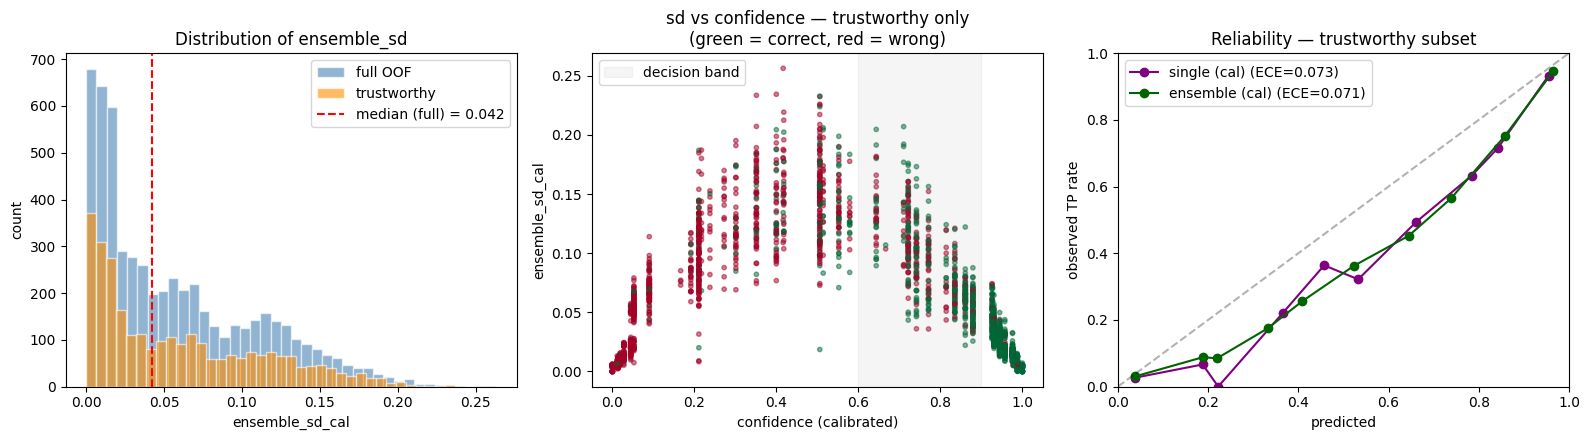

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) sd histogram — full vs trustworthy
axes[0].hist(oof_ens_sd_cal, bins=40, color='steelblue', edgecolor='white',
             alpha=0.6, label='full OOF')
axes[0].hist(oof_ens_sd_cal[trustworthy_valid], bins=40, color='darkorange',
             edgecolor='white', alpha=0.6, label='trustworthy')
axes[0].axvline(np.median(oof_ens_sd_cal), color='red', linestyle='--',
                label=f'median (full) = {np.median(oof_ens_sd_cal):.3f}')
axes[0].set_xlabel('ensemble_sd_cal')
axes[0].set_ylabel('count')
axes[0].set_title('Distribution of ensemble_sd')
axes[0].legend()

# (b) sd vs confidence on trustworthy subset, colored by label
axes[1].scatter(oof_ens_cal[trustworthy_valid], oof_ens_sd_cal[trustworthy_valid],
                c=y_valid[trustworthy_valid], s=10, alpha=0.5,
                cmap='RdYlGn', vmin=0, vmax=1)
axes[1].axvspan(0.6, 0.9, alpha=0.08, color='gray', label='decision band')
axes[1].set_xlabel('confidence (calibrated)')
axes[1].set_ylabel('ensemble_sd_cal')
axes[1].set_title('sd vs confidence — trustworthy only\n(green = correct, red = wrong)')
axes[1].legend()

# (c) Reliability — single vs ensemble on trustworthy subset
nbins = 10
edges = np.linspace(0, 1, nbins + 1)
for name, p, color in [('single (cal)', oof_single_cal[trustworthy_valid], 'purple'),
                       ('ensemble (cal)', oof_ens_cal[trustworthy_valid], 'darkgreen')]:
    yv = y_valid[trustworthy_valid]
    bi = np.clip(np.digitize(p, edges[1:-1]), 0, nbins - 1)
    bc, bf = [], []
    for b in range(nbins):
        m = bi == b
        if m.sum() == 0:
            continue
        bc.append(p[m].mean())
        bf.append(yv[m].mean())
    axes[2].plot(bc, bf, 'o-', label=f'{name} (ECE={ece(p, yv):.3f})', color=color)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[2].set_xlabel('predicted')
axes[2].set_ylabel('observed TP rate')
axes[2].set_title('Reliability — trustworthy subset')
axes[2].legend()
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 9. Decision summary

In [10]:
print('=' * 72)
print('BOOTSTRAP ENSEMBLE — DECISION SUMMARY')
print('=' * 72)
print(f'K = {K}   group-block bootstrap on anno_ik14   {N_FOLDS}-fold GroupKFold')
print()
yv_tr = y_valid[trustworthy_valid]
print(f'Headline metrics — trustworthy subset (n={trustworthy_valid.sum():,}):')
print(f'  single   AUC={roc_auc_score(yv_tr, oof_single[valid][trustworthy_valid]):.4f}  '
      f'Brier={brier_score_loss(yv_tr, oof_single_cal[trustworthy_valid]):.4f}  '
      f'ECE={ece(oof_single_cal[trustworthy_valid], yv_tr):.4f}')
print(f'  ensemble AUC={roc_auc_score(yv_tr, oof_ens[valid][trustworthy_valid]):.4f}  '
      f'Brier={brier_score_loss(yv_tr, oof_ens_cal[trustworthy_valid]):.4f}  '
      f'ECE={ece(oof_ens_cal[trustworthy_valid], yv_tr):.4f}')
print()
print('Falsifiable tests (trustworthy subset drives decision):')
print(f'  (1) [0.6, 0.9] band error ratio   : full={band_ratio_full:.2f}x   trustworthy={band_ratio_trust:.2f}x')
print(f'  (2) FP ≥0.7 concentration ratio   : full={fp_ratio_full:.2f}x   trustworthy={fp_ratio_trust:.2f}x')
print()
if band_ratio_trust >= 1.5 and fp_ratio_trust >= 1.5:
    verdict = 'SHIP — ensemble_sd separates errors on trustworthy labels. Wire into deliverable.'
elif band_ratio_trust < 1.2 and fp_ratio_trust < 1.2:
    verdict = 'DROP — bootstrap does not separate errors at this scale. Record outcome in memory.'
else:
    verdict = 'INSPECT — mixed signal. Look at high-sd bins manually before deciding.'
print(f'=> {verdict}')

BOOTSTRAP ENSEMBLE — DECISION SUMMARY
K = 10   group-block bootstrap on anno_ik14   5-fold GroupKFold

Headline metrics — trustworthy subset (n=2,835):
  single   AUC=0.9261  Brier=0.1150  ECE=0.0730
  ensemble AUC=0.9286  Brier=0.1134  ECE=0.0712

Falsifiable tests (trustworthy subset drives decision):
  (1) [0.6, 0.9] band error ratio   : full=1.45x   trustworthy=1.41x
  (2) FP ≥0.7 concentration ratio   : full=2.72x   trustworthy=2.88x

=> INSPECT — mixed signal. Look at high-sd bins manually before deciding.


## 10. Refit isotonic on trustworthy labels — compare calibration

Production fits isotonic on the full OOF set, where 50% of the positives are unreviewed singleton-TPs. Result: calibration is tight on the mixed population (ECE ≈ 0) but off on the verified slice (ECE = 0.077 on trustworthy). Here we refit isotonic on the trustworthy OOF only, apply it everywhere, and rerun the falsifiable tests under the new calibration.

In [11]:
# Fit isotonic on trustworthy OOF only
iso_single_trust = IsotonicRegression(out_of_bounds='clip').fit(
    oof_single[valid][trustworthy_valid], y_valid[trustworthy_valid])
iso_ens_trust = IsotonicRegression(out_of_bounds='clip').fit(
    oof_ens[valid][trustworthy_valid], y_valid[trustworthy_valid])

# Apply trustworthy-fit isotonic to all OOF preds (so calibration can be evaluated on both subsets)
oof_single_cal_t = iso_single_trust.transform(oof_single[valid])
oof_ens_cal_t    = iso_ens_trust.transform(oof_ens[valid])

# Recompute ensemble_sd in calibrated space under the new isotonic
oof_per_k_cal_t = np.array([iso_ens_trust.transform(oof_per_k[k, valid]) for k in range(K)])
oof_ens_sd_cal_t = oof_per_k_cal_t.std(axis=0)

# Calibration comparison table
rows = []
for cal_name, p_s, p_e in [
    ('production iso (full)',   oof_single_cal,   oof_ens_cal),
    ('trustworthy iso (subset)', oof_single_cal_t, oof_ens_cal_t),
]:
    for subset_name, sm in [('full', np.ones(len(y_valid), dtype=bool)),
                             ('trustworthy', trustworthy_valid)]:
        for model_name, p in [('single', p_s), ('ensemble', p_e)]:
            yv = y_valid[sm]
            pp = p[sm]
            rows.append({
                'cal': cal_name, 'subset': subset_name, 'model': model_name,
                'n': int(sm.sum()),
                'Brier': brier_score_loss(yv, pp),
                'ECE':   ece(pp, yv),
            })
cal_compare = pd.DataFrame(rows).set_index(['cal', 'subset', 'model'])
cal_compare

n     Brier           ECE
cal                      subset      model                                 
production iso (full)    full        single    5658  0.102792  1.107672e-17
                                     ensemble  5658  0.101239  2.030896e-18
                         trustworthy single    2835  0.114960  7.302825e-02
                                     ensemble  2835  0.113422  7.120172e-02
trustworthy iso (subset) full        single    5658  0.113644  7.485341e-02
                                     ensemble  5658  0.112140  7.397919e-02
                         trustworthy single    2835  0.104150  3.757527e-17
                                     ensemble  2835  0.102588  9.398713e-18

In [12]:
# Re-run falsifiable tests under trustworthy isotonic
def band_test(label, eval_mask, p_cal, sd_cal):
    p, y, sd = p_cal[eval_mask], y_valid[eval_mask], sd_cal[eval_mask]
    band = (p >= 0.6) & (p <= 0.9)
    if band.sum() < 20:
        print(f'{label}: band too small (n={band.sum()})'); return np.nan
    p_b, y_b, sd_b = p[band], y[band], sd[band]
    med = np.median(sd_b)
    lo, hi = sd_b <= med, sd_b > med
    err_lo = np.abs(p_b[lo] - y_b[lo]).mean()
    err_hi = np.abs(p_b[hi] - y_b[hi]).mean()
    ratio = err_hi / err_lo if err_lo > 0 else np.inf
    print(f'{label:>14s}: n_band={band.sum():4d}  med_sd={med:.3f}  '
          f'low-err={err_lo:.3f}  high-err={err_hi:.3f}  ratio={ratio:.2f}x')
    return ratio

def fp_test(label, eval_mask, p_cal, sd_cal):
    p, y, sd = p_cal[eval_mask], y_valid[eval_mask], sd_cal[eval_mask]
    fp_hi_conf = (y == 0) & (p >= 0.7)
    if fp_hi_conf.sum() == 0:
        print(f'{label}: no FPs ≥ 0.7'); return np.nan
    med = np.median(sd)
    n_hi = (fp_hi_conf & (sd > med)).sum()
    n_lo = (fp_hi_conf & (sd <= med)).sum()
    ratio = n_hi / max(n_lo, 1)
    print(f'{label:>14s}: n_FP={(y==0).sum():4d}  FP≥0.7={fp_hi_conf.sum():4d}  '
          f'high-sd={n_hi:4d}  low-sd={n_lo:4d}  ratio={ratio:.2f}x')
    return ratio

print('Falsifiable test 1 (band error rate) under TRUSTWORTHY isotonic')
print('-' * 78)
band_full_t  = band_test('full',        np.ones(len(y_valid), dtype=bool),
                          oof_ens_cal_t, oof_ens_sd_cal_t)
band_trust_t = band_test('trustworthy', trustworthy_valid,
                          oof_ens_cal_t, oof_ens_sd_cal_t)
print()
print('Falsifiable test 2 (FP ≥0.7 concentration) under TRUSTWORTHY isotonic')
print('-' * 78)
fp_full_t  = fp_test('full',        np.ones(len(y_valid), dtype=bool),
                      oof_ens_cal_t, oof_ens_sd_cal_t)
fp_trust_t = fp_test('trustworthy', trustworthy_valid,
                      oof_ens_cal_t, oof_ens_sd_cal_t)
print()
print(f'Comparison vs production isotonic:')
print(f'  Test 1 (band)   : production trust={band_ratio_trust:.2f}x  →  trustworthy iso={band_trust_t:.2f}x')
print(f'  Test 2 (FP@≥0.7): production trust={fp_ratio_trust:.2f}x  →  trustworthy iso={fp_trust_t:.2f}x')

Falsifiable test 1 (band error rate) under TRUSTWORTHY isotonic
------------------------------------------------------------------------------
          full: n_band=1115  med_sd=0.116  low-err=0.311  high-err=0.371  ratio=1.19x
   trustworthy: n_band= 439  med_sd=0.118  low-err=0.349  high-err=0.420  ratio=1.20x

Falsifiable test 2 (FP ≥0.7 concentration) under TRUSTWORTHY isotonic
------------------------------------------------------------------------------
          full: n_FP=1766  FP≥0.7= 170  high-sd= 115  low-sd=  55  ratio=2.09x
   trustworthy: n_FP=1335  FP≥0.7= 106  high-sd=  76  low-sd=  30  ratio=2.53x

Comparison vs production isotonic:
  Test 1 (band)   : production trust=1.41x  →  trustworthy iso=1.20x
  Test 2 (FP@≥0.7): production trust=2.88x  →  trustworthy iso=2.53x


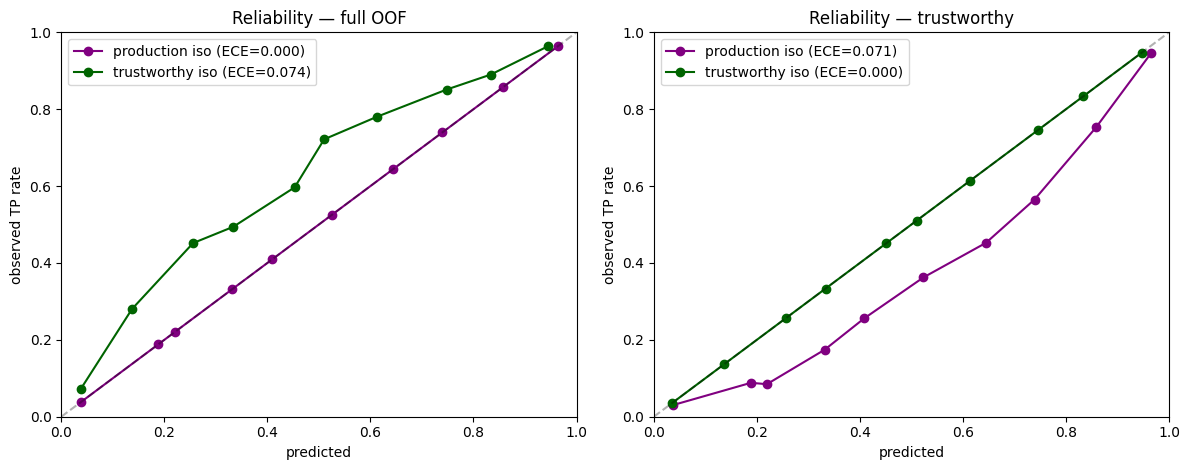

In [13]:
# Reliability — production iso vs trustworthy iso, side by side on each subset
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
nbins = 10
edges = np.linspace(0, 1, nbins + 1)

for ax, (subset_name, sm) in zip(axes, [('full OOF',     np.ones(len(y_valid), dtype=bool)),
                                          ('trustworthy', trustworthy_valid)]):
    for label, p, color in [
        ('production iso', oof_ens_cal[sm],   'purple'),
        ('trustworthy iso', oof_ens_cal_t[sm], 'darkgreen'),
    ]:
        yv = y_valid[sm]
        bi = np.clip(np.digitize(p, edges[1:-1]), 0, nbins - 1)
        bc, bf = [], []
        for b in range(nbins):
            m = bi == b
            if m.sum() == 0: continue
            bc.append(p[m].mean()); bf.append(yv[m].mean())
        ax.plot(bc, bf, 'o-', label=f'{label} (ECE={ece(p, yv):.3f})', color=color)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('predicted'); ax.set_ylabel('observed TP rate')
    ax.set_title(f'Reliability — {subset_name}')
    ax.legend(); ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout(); plt.show()

## 11. (Optional) Export OOF dataframe for follow-up inspection

Saves a dataframe with `wiki_id`, `is_oliver_reviewed`, `confidence_single`, `confidence_ensemble`, `ensemble_sd_cal`, label, and a few key features so you can browse the high-sd bins. Not written by default — uncomment to save.

In [14]:
oof_df = top1_train.loc[valid, ['wiki_id', 'name', 'adduct', 'anno_ik14',
                                'spectrum_label', 'hit_label', 'is_oliver_reviewed',
                                'entropy_similarity', 'sim_gap',
                                'signed_delta_rt', 'delta_mda']].copy()
oof_df['confidence_single'] = oof_single_cal
oof_df['confidence_ensemble'] = oof_ens_cal
oof_df['ensemble_sd_cal'] = oof_ens_sd_cal
oof_df = oof_df.sort_values('ensemble_sd_cal', ascending=False).reset_index(drop=True)

print('Top 10 highest-sd OOF bins (trustworthy only):')
oof_df[oof_df['is_oliver_reviewed']].head(10)

# Uncomment to save:
# oof_df.to_csv(os.path.join(ROOT, 'data', 'bench_bootstrap_oof.csv'), index=False)
# print('Saved data/bench_bootstrap_oof.csv')

Top 10 highest-sd OOF bins (trustworthy only):


,wiki_id,name,adduct,anno_ik14,spectrum_label,hit_label,is_oliver_reviewed,entropy_similarity,sim_gap,signed_delta_rt,delta_mda,confidence_single,confidence_ensemble,ensemble_sd_cal
1,aEKJ9AS/10690,ALLOTHREONINE,M-2H2O+H,AYFVYJQAPQTCCC,FP,0,True,0.675352,0.675352,-6.7,0.529085,0.364130,0.416667,0.256288
3,aPUDE1U/1184,3-Hydroxy-1-propanesulfonic acid,[M-H]-,WQPMYSHJKXVTME,FP,0,True,0.999223,0.581667,-54.6,0.576841,0.561497,0.400000,0.234325
4,aEKJ9AS/3562,ALLOTHREONINE,M-2H2O+H,AYFVYJQAPQTCCC,FP,0,True,0.669550,0.669550,8.8,0.599310,0.187713,0.351351,0.233459
5,aPUDE1U/2038,Hexanoyl coenzyme A,[M-2H]2-,OEXFMSFODMQEPE,TP,1,True,0.818823,0.818823,-61.6,0.456443,0.364130,0.506024,0.232735
6,aPUDE1U/1913,Chlorhexidine Base,[M+FA]-,GHXZTYHSJHQHIJ,FP,0,True,0.912321,0.678814,-39.7,1006.886776,0.561497,0.506024,0.232332
7,aPUDE1U/1788,"""2,4-DIHYDROXYBUTANOIC ACID""",M-H,UFYGCFHQAXXBCF,FP,0,True,0.730142,0.604576,-38.8,0.580400,0.649057,0.506024,0.225915
9,aEKJ9AS/8292,1-Palmitoylglycerophosphocholine,[M]+,ASWBNKHCZGQVJV,FP,0,True,0.886257,0.886257,46.0,1007.632918,0.390805,0.506024,0.225127
10,aPUDE1U/1639,Hexanoyl coenzyme A,[M-H]-,OEXFMSFODMQEPE,TP,1,True,0.901039,0.901039,-61.5,1.846007,0.350877,0.506024,0.223776
13,aPUDE1U/2533,Acamprosate,[2M-H]-,AFCGFAGUEYAMAO,FP,0,True,0.736860,0.173995,-42.3,0.662771,0.649057,0.418182,0.219190
16,aEKJ9AS/13601,"9,12,14-Octadecatrienoic acid, 16-oxo-, (9Z,12...",[M+H-H2O]+,RHVWQVSLVMXMBR,FP,0,True,0.924706,0.009230,-4.7,0.297394,0.508108,0.506024,0.217206
